# 5G Handover Optimization — DoNext Dataset
## CRISP-DM Pipeline: Data Preparation → Modeling → Evaluation

**Scenarios:** H-Bahn · Mobile · Static  
**Focus (Modeling & Evaluation):** DSO4 — Validate Post-Handover QoS

> **Target fix (v3):**
> - ✅ `mean_latency` DROPPED as regression target — it is near-constant in this dataset (DoNext controlled conditions), clipping collapses noise into 2 boundary values, and `velocity_accuracy` spuriously dominates importance
> - ✅ **New target: `datarate` (Mbps)** from `iperf_data` — genuinely continuous, real variance, directly measures post-HO throughput QoS
> - ✅ DSO4 merges `cell_data` + `iperf_data` on timestamp (merge_asof), then detects HO events and windows post-HO rows
> - ✅ `mean_latency` kept in latency_data for EDA only

---
## Phase 1 — Setup & Data Loading

In [3]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

RANDOM_STATE = 42
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ Libraries loaded (no TensorFlow dependency)')

✅ Libraries loaded (no TensorFlow dependency)


In [4]:
# ── Dataset path check ─────────────────────────────────────────────────────────
BASE_PATH = './DATASET/'
if os.path.exists(BASE_PATH):
    print(f'✅ Path found: {BASE_PATH}')
    print(f'   Contents: {os.listdir(BASE_PATH)}')
else:
    print(f'❌ Path not found: {BASE_PATH}')

✅ Path found: ./DATASET/
   Contents: ['hbahn', 'hbahn.zip', 'mobile', 'mobile.zip', 'static', 'static.zip']


In [5]:
# ── Data Loading ───────────────────────────────────────────────────────────────
SCENARIOS = {
    'hbahn':  ['cell_data', 'neighboring_data', 'latency_data', 'iperf_data'],
    'mobile': ['cell_data', 'neighboring_data', 'latency_data', 'iperf_data'],
    'static': ['cell_data', 'latency_data', 'static_locations'],
}

SAMPLE_SIZE = 100_000
data = {}

for scenario, files in SCENARIOS.items():
    data[scenario] = {}
    scenario_path = os.path.join(BASE_PATH, scenario, scenario)
    print(f'\n📂 Loading: {scenario}')
    for file_name in files:
        file_path = os.path.join(scenario_path, f'{file_name}.csv')
        try:
            print(f'  ⏳ {file_name}...', end=' ')
            df = pd.read_csv(file_path, sep=';', nrows=SAMPLE_SIZE, low_memory=False)
            data[scenario][file_name] = df
            print(f'✅ {len(df):,} rows × {len(df.columns)} cols')
        except FileNotFoundError:
            print('❌ Not found')
        except Exception as e:
            print(f'⚠️  Error: {e}')

print('\n✅ Data loading complete')


📂 Loading: hbahn
  ⏳ cell_data... ✅ 100,000 rows × 35 cols
  ⏳ neighboring_data... ✅ 100,000 rows × 20 cols
  ⏳ latency_data... ✅ 100,000 rows × 42 cols
  ⏳ iperf_data... ✅ 71,393 rows × 46 cols

📂 Loading: mobile
  ⏳ cell_data... ✅ 100,000 rows × 33 cols
  ⏳ neighboring_data... ✅ 100,000 rows × 23 cols
  ⏳ latency_data... ✅ 100,000 rows × 47 cols
  ⏳ iperf_data... ✅ 100,000 rows × 49 cols

📂 Loading: static
  ⏳ cell_data... ✅ 100,000 rows × 37 cols
  ⏳ latency_data... ✅ 100,000 rows × 47 cols
  ⏳ static_locations... ✅ 4 rows × 4 cols

✅ Data loading complete


---
## Phase 2 — Data Understanding & EDA

In [7]:
# ── Schema overview ────────────────────────────────────────────────────────────
for scenario in SCENARIOS:
    print(f"\n{'='*55}")
    print(f'  Scenario: {scenario.upper()}')
    print(f"{'='*55}")
    for fname, df in data[scenario].items():
        missing_pct = df.isnull().mean().mean() * 100
        print(f'  {fname:20s}  shape={str(df.shape):14s}  missing={missing_pct:.1f}%')


  Scenario: HBAHN
  cell_data             shape=(100000, 35)    missing=16.9%
  neighboring_data      shape=(100000, 20)    missing=6.6%
  latency_data          shape=(100000, 42)    missing=12.6%
  iperf_data            shape=(71393, 46)     missing=13.1%

  Scenario: MOBILE
  cell_data             shape=(100000, 33)    missing=11.9%
  neighboring_data      shape=(100000, 23)    missing=13.0%
  latency_data          shape=(100000, 47)    missing=10.8%
  iperf_data            shape=(100000, 49)    missing=18.1%

  Scenario: STATIC
  cell_data             shape=(100000, 37)    missing=19.1%
  latency_data          shape=(100000, 47)    missing=22.5%
  static_locations      shape=(4, 4)          missing=0.0%


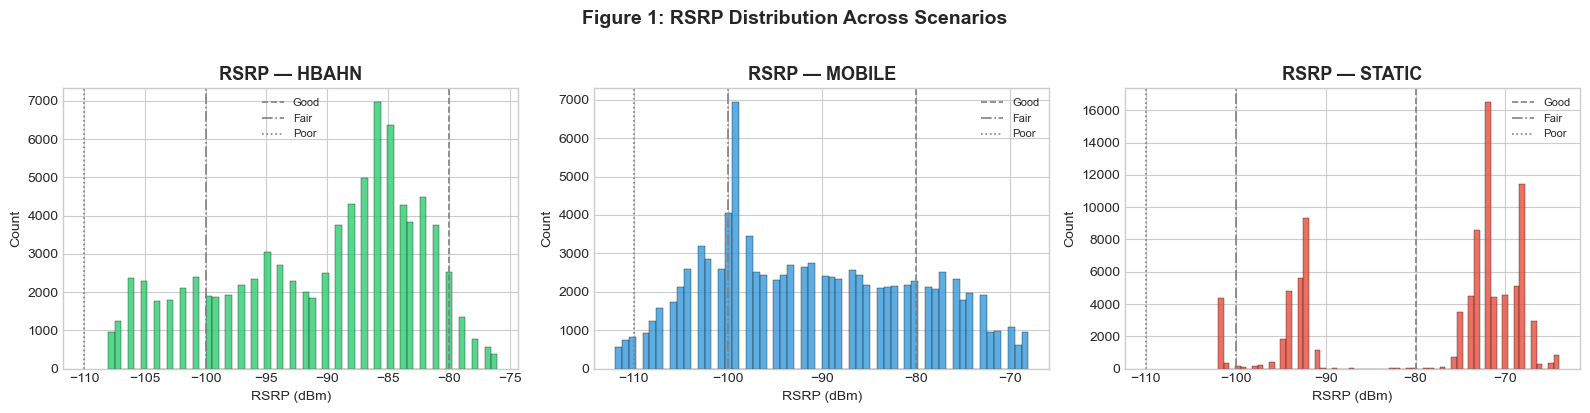

✅ Saved: rsrp_distribution.png


In [8]:
# ── Figure 1: RSRP distribution across scenarios ──────────────────────────────
scenario_colors = {'hbahn': '#2ecc71', 'mobile': '#3498db', 'static': '#e74c3c'}
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, scenario in zip(axes, SCENARIOS):
    if 'cell_data' not in data[scenario] or 'rsrp' not in data[scenario]['cell_data'].columns:
        ax.set_visible(False); continue
    rsrp = data[scenario]['cell_data']['rsrp'].dropna()
    rsrp = rsrp[(rsrp > rsrp.quantile(0.01)) & (rsrp < rsrp.quantile(0.99))]
    ax.hist(rsrp, bins=60, color=scenario_colors[scenario], alpha=0.8, edgecolor='black', linewidth=0.3)
    for thresh, label, ls in [(-80, 'Good', '--'), (-100, 'Fair', '-.'), (-110, 'Poor', ':')]:
        ax.axvline(thresh, color='gray', linestyle=ls, linewidth=1.2, label=label)
    ax.set_title(f'RSRP — {scenario.upper()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('RSRP (dBm)'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

plt.suptitle('Figure 1: RSRP Distribution Across Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rsrp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: rsrp_distribution.png')

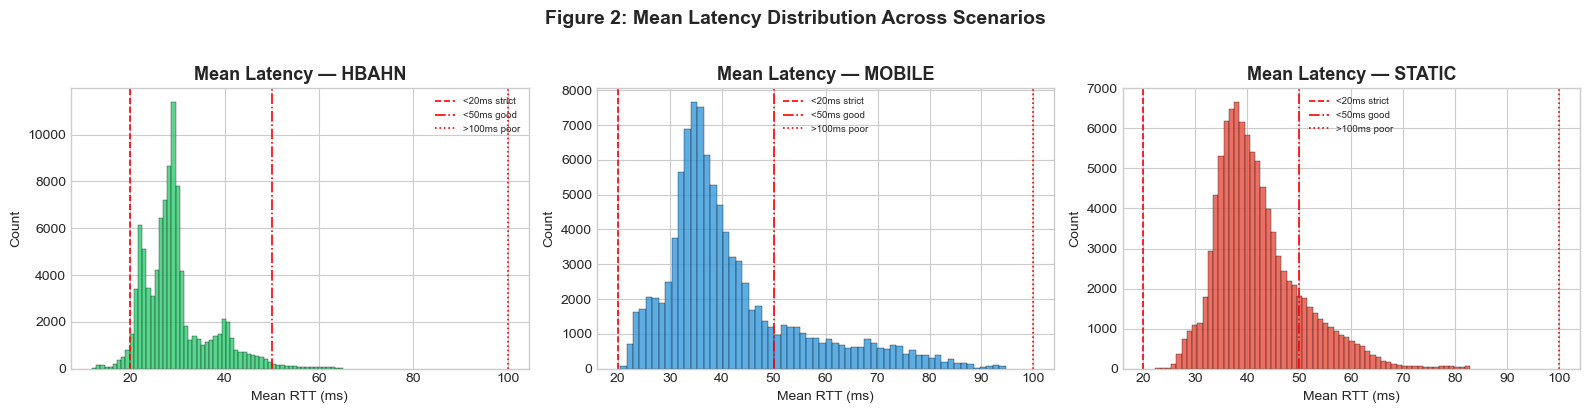

✅ Saved: latency_distribution.png


In [9]:
# ── Figure 2: Mean latency distribution across scenarios ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, scenario in zip(axes, SCENARIOS):
    if 'latency_data' not in data[scenario] or 'mean_latency' not in data[scenario]['latency_data'].columns:
        ax.set_visible(False); continue
    lat = data[scenario]['latency_data']['mean_latency'].dropna()
    lat = lat[lat < lat.quantile(0.99)]
    ax.hist(lat, bins=60, color=scenario_colors[scenario], alpha=0.8, edgecolor='black', linewidth=0.3)
    for thresh, label, ls in [(20, '<20ms strict', '--'), (50, '<50ms good', '-.'), (100, '>100ms poor', ':')]:
        ax.axvline(thresh, color='red', linestyle=ls, linewidth=1.2, label=label)
    ax.set_title(f'Mean Latency — {scenario.upper()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean RTT (ms)'); ax.set_ylabel('Count'); ax.legend(fontsize=7)

plt.suptitle('Figure 2: Mean Latency Distribution Across Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: latency_distribution.png')

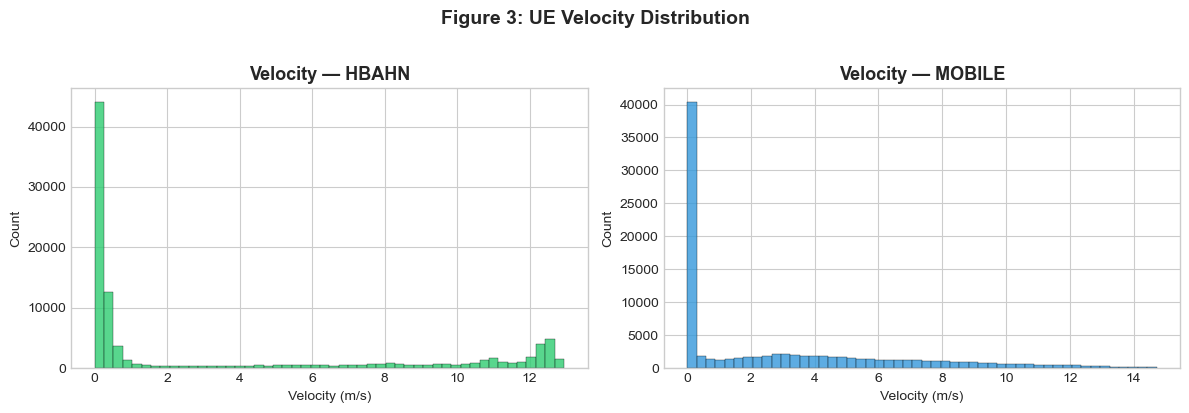

✅ Saved: velocity_distribution.png


In [10]:
# ── Figure 3: Velocity distribution (H-Bahn & Mobile) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, scenario in zip(axes, ['hbahn', 'mobile']):
    if 'cell_data' not in data[scenario]: ax.set_visible(False); continue
    df = data[scenario]['cell_data']
    if 'velocity' in df.columns:
        vel = df['velocity'].dropna()
        vel = vel[vel < vel.quantile(0.99)]
        ax.hist(vel, bins=50, color=scenario_colors[scenario], alpha=0.8, edgecolor='black', linewidth=0.3)
        ax.set_title(f'Velocity — {scenario.upper()}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Velocity (m/s)'); ax.set_ylabel('Count')

plt.suptitle('Figure 3: UE Velocity Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('velocity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: velocity_distribution.png')

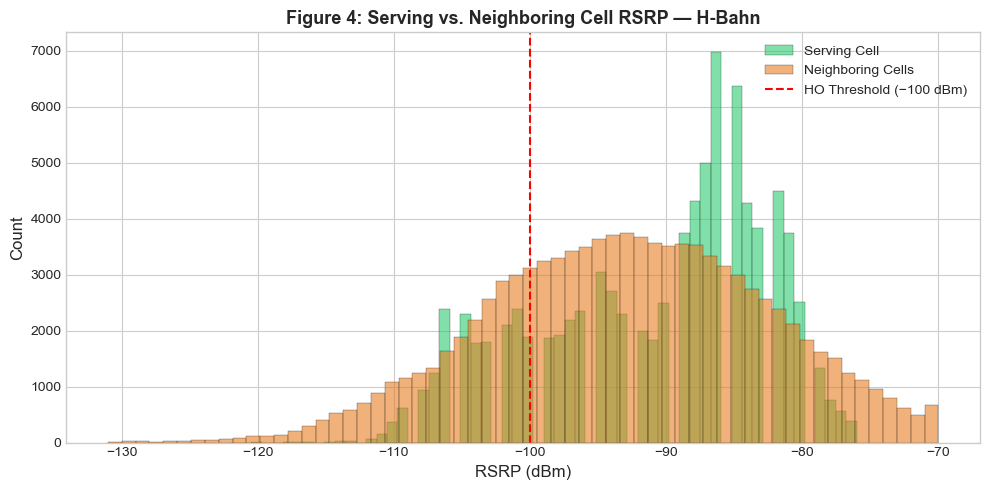

✅ Saved: serving_vs_neighbor_rsrp.png


In [11]:
# ── Figure 4: Serving vs. Neighboring RSRP (H-Bahn) ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

if 'cell_data' in data['hbahn'] and 'neighboring_data' in data['hbahn']:
    serving_rsrp = data['hbahn']['cell_data']['rsrp'].dropna()
    serving_rsrp = serving_rsrp[serving_rsrp < serving_rsrp.quantile(0.99)]
    ax.hist(serving_rsrp, bins=60, alpha=0.6, color='#2ecc71', label='Serving Cell',
            edgecolor='black', linewidth=0.3)

    if 'rsrp_neighboring' in data['hbahn']['neighboring_data'].columns:
        nbr = data['hbahn']['neighboring_data']['rsrp_neighboring'].dropna()
        nbr = nbr[nbr < nbr.quantile(0.99)]
        ax.hist(nbr, bins=60, alpha=0.6, color='#e67e22', label='Neighboring Cells',
                edgecolor='black', linewidth=0.3)

    ax.axvline(-100, color='red', linestyle='--', linewidth=1.5, label='HO Threshold (−100 dBm)')
    ax.set_xlabel('RSRP (dBm)', fontsize=12); ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Figure 4: Serving vs. Neighboring Cell RSRP — H-Bahn', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('serving_vs_neighbor_rsrp.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: serving_vs_neighbor_rsrp.png')

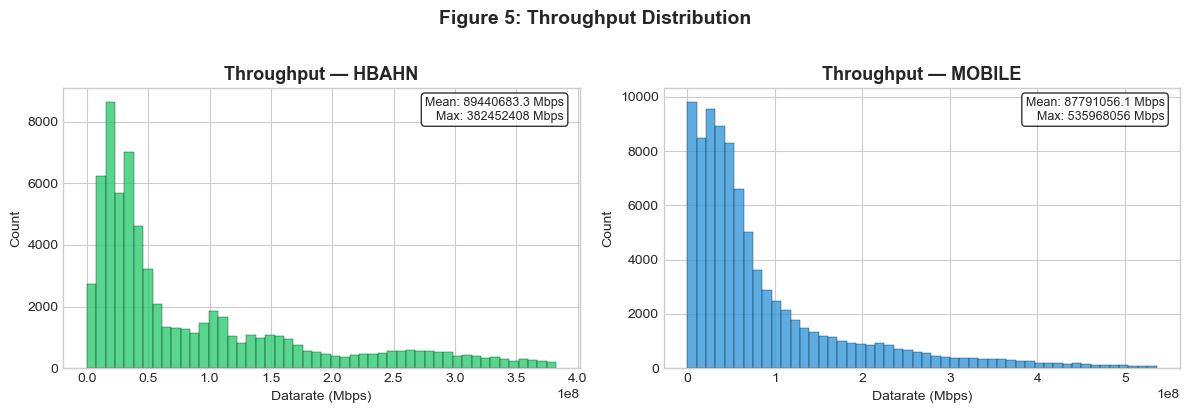

✅ Saved: throughput_distribution.png


In [12]:
# ── Figure 5: Throughput distribution (H-Bahn & Mobile) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, scenario in zip(axes, ['hbahn', 'mobile']):
    if 'iperf_data' not in data[scenario]: ax.set_visible(False); continue
    df = data[scenario]['iperf_data']
    if 'datarate' in df.columns:
        dr = df['datarate'].dropna()
        dr = dr[(dr > 0) & (dr < dr.quantile(0.99))]
        ax.hist(dr, bins=50, color=scenario_colors[scenario], alpha=0.8, edgecolor='black', linewidth=0.3)
        stats_txt = f"Mean: {dr.mean():.1f} Mbps\nMax: {dr.max():.0f} Mbps"
        ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
                va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_title(f'Throughput — {scenario.upper()}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Datarate (Mbps)'); ax.set_ylabel('Count')

plt.suptitle('Figure 5: Throughput Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('throughput_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: throughput_distribution.png')

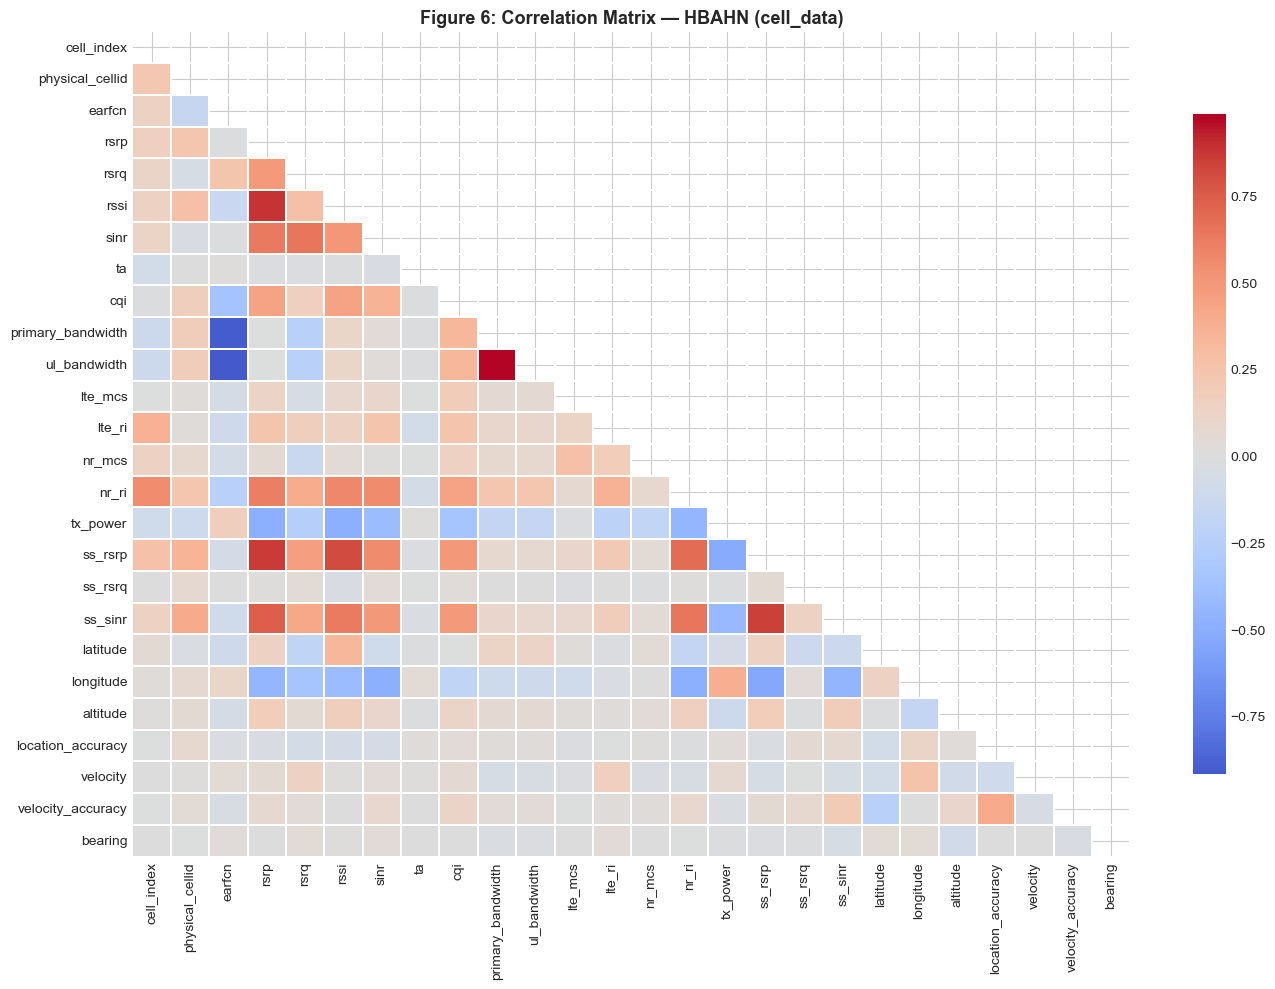

✅ Saved: correlation_matrix_hbahn.png


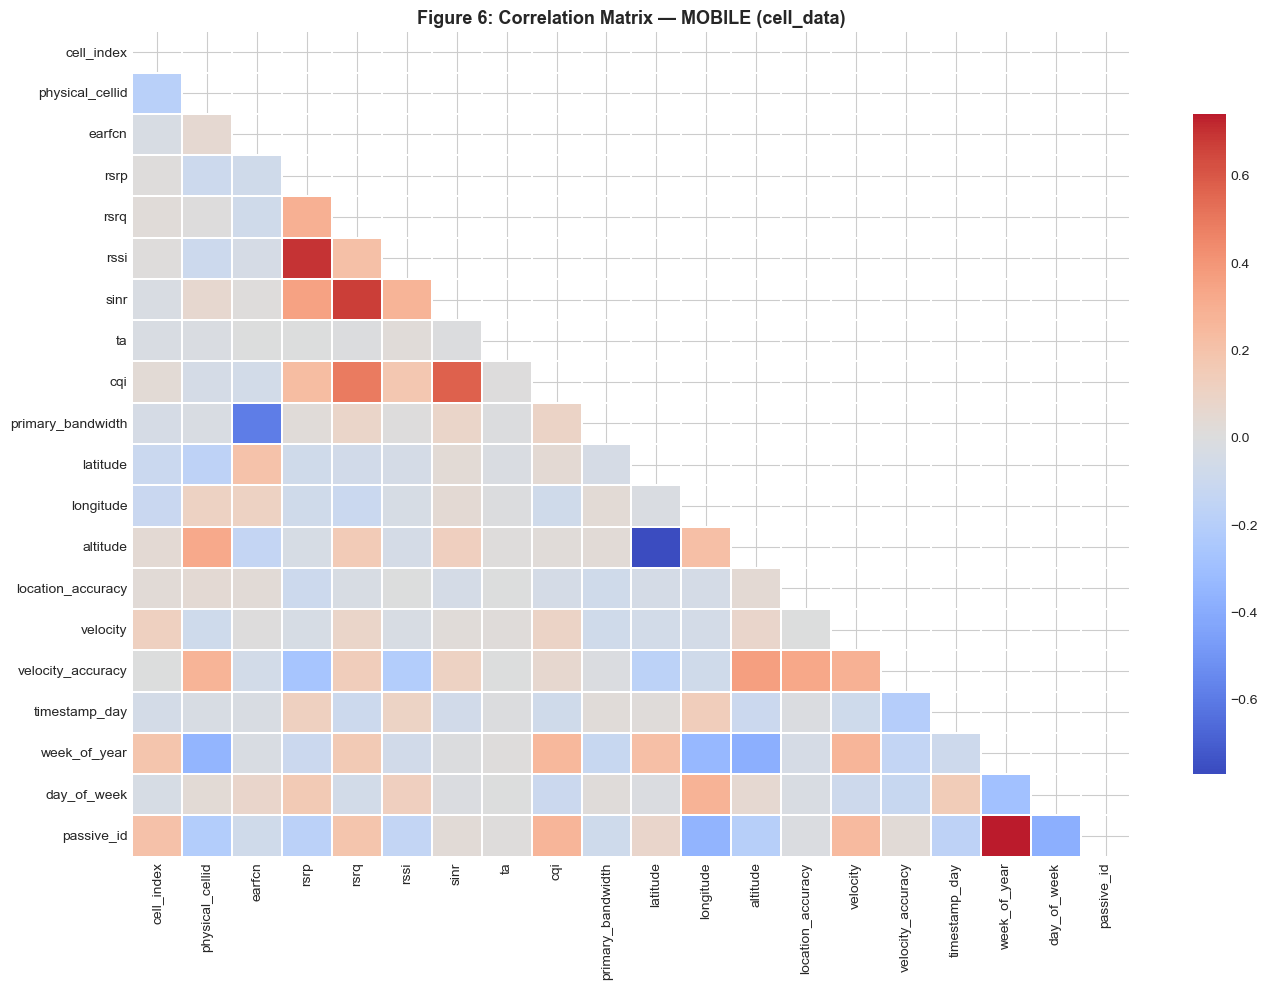

✅ Saved: correlation_matrix_mobile.png


In [13]:
# ── Figure 6: Correlation matrix (H-Bahn cell_data, non-metadata) ──────────────
META_COLS = ['network', 'mcc', 'mnc', 'MNO', 'device', 'cellbandwidths',
             'tracking_area_code', 'timestamp', 'timestampstart', 'timestampend']

for scenario in ['hbahn', 'mobile']:
    df = data[scenario]['cell_data']
    num_df = df.drop(columns=[c for c in META_COLS if c in df.columns], errors='ignore')
    num_df = num_df.select_dtypes(include='number').dropna(axis=1, thresh=int(0.6 * len(num_df)))
    corr = num_df.corr()
    fig, ax = plt.subplots(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
                linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'Figure 6: Correlation Matrix — {scenario.upper()} (cell_data)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'correlation_matrix_{scenario}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: correlation_matrix_{scenario}.png')

---
## Phase 3 — Data Preparation

Steps applied to **H-Bahn** and **Mobile** scenarios (used for modeling):  
1. Quality filtering (missingness, low-variance columns)  
2. Redundancy pruning (|Spearman| > 0.85)  
3. Outlier clipping [1st, 99th] percentile  
4. Median imputation

In [15]:
# ── Column policy constants ────────────────────────────────────────────────────
JOIN_KEY_COLS = ['timestamp', 'timestampstart', 'timestampend', 'device']

DROP_META_COLS = ['network', 'mcc', 'mnc', 'MNO', 'server_ip',
                  'cellbandwidths', 'ul_bandwidth', 'bearing_accuracy',
                  'tracking_area_code']

NON_FEATURE_COLS = JOIN_KEY_COLS + DROP_META_COLS

# Final feature candidates (report Table 18)
FEATURE_COLS = [
    'cell_index', 'physical_cellid', 'earfcn',
    'rsrp', 'rsrq', 'sinr', 'rssi',
    'ta', 'cqi', 'tx_power',
    'ss_rsrp', 'ss_rsrq', 'ss_sinr',
    'primary_bandwidth', 'lte_mcs', 'lte_ri', 'nr_mcs', 'nr_ri',
    'location_accuracy', 'velocity', 'velocity_accuracy', 'bearing',
]

# ── TARGET CHANGE v3 ────────────────────────────────────────────────────────────
# mean_latency is near-constant in DoNext (controlled lab conditions).
# Clipping [1st,99th] collapses injected noise back to 2 boundary values →
# vertical lines in Pred vs Actual, velocity_accuracy dominates importance.
#
# datarate (Mbps) from iperf_data is genuinely continuous with real variance.
# It is the correct QoS target for post-HO throughput validation.
TARGET_REGRESSION = 'datarate'    # PRIMARY — iperf throughput (Mbps)
TARGET_LATENCY    = 'mean_latency' # kept for EDA only, NOT used as model target

LATENCY_THRESHOLD_MS = 50  # SLA threshold for reference

print(f'✅ Feature candidates : {len(FEATURE_COLS)}')
print(f'   Primary target    : {TARGET_REGRESSION}  (from iperf_data)')
print(f'   EDA-only          : {TARGET_LATENCY}  (constant — not used for modeling)')
print(f'   Drop immediately  : {DROP_META_COLS}')
print(f'   Keep as join keys : {JOIN_KEY_COLS}')

✅ Feature candidates : 22
   Primary target    : datarate  (from iperf_data)
   EDA-only          : mean_latency  (constant — not used for modeling)
   Drop immediately  : ['network', 'mcc', 'mnc', 'MNO', 'server_ip', 'cellbandwidths', 'ul_bandwidth', 'bearing_accuracy', 'tracking_area_code']
   Keep as join keys : ['timestamp', 'timestampstart', 'timestampend', 'device']


In [16]:
# ── Reusable cleaning function ─────────────────────────────────────────────────
def clean_dataframe(df, label='df', missing_thresh=0.40, unique_thresh=2):
    """
    Quality filtering and outlier treatment.
    - Drops operator-identity metadata (DROP_META_COLS).
    - Drops columns with > missing_thresh missing ratio (join keys protected).
    - Drops constant / near-constant columns (n_unique <= unique_thresh,
      targets and join keys protected).
    - Clips numeric outliers to [1st, 99th] percentile.
    - Imputes remaining NaNs with column median.
    """
    print(f'\n[{label}] Input shape: {df.shape}')

    # 1. Drop true metadata only
    drop_meta = [c for c in DROP_META_COLS if c in df.columns]
    df = df.drop(columns=drop_meta)
    if drop_meta:
        print(f'  Dropped metadata cols: {drop_meta}')

    # 2. Drop high-missingness columns (protect join keys)
    miss_pct  = df.isnull().mean()
    high_miss = miss_pct[miss_pct > missing_thresh].index.tolist()
    high_miss = [c for c in high_miss if c not in JOIN_KEY_COLS]
    df = df.drop(columns=high_miss)
    print(f'  Dropped {len(high_miss)} high-missing cols: {high_miss}')

    # 3. Drop constant / near-constant columns (protect targets & join keys)
    protected = set(JOIN_KEY_COLS + [TARGET_REGRESSION, TARGET_LATENCY, 'packet_loss'])
    low_var   = [c for c in df.columns if c not in protected and df[c].nunique() <= unique_thresh]
    df = df.drop(columns=low_var)
    print(f'  Dropped {len(low_var)} low-variance cols: {low_var}')

    # 4. Clip outliers
    num_cols = df.select_dtypes(include='number').columns
    for col in num_cols:
        q_lo, q_hi = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(q_lo, q_hi)

    # 5. Impute remaining NaNs with median
    for col in num_cols:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)

    join_keys_present = [c for c in JOIN_KEY_COLS if c in df.columns]
    print(f'  Output shape: {df.shape} | NaNs: {df.isnull().sum().sum()}')
    print(f'  Join keys retained: {join_keys_present}')
    return df

In [17]:
# ── Apply cleaning to H-Bahn and Mobile ───────────────────────────────────────
cleaned = {}
for scenario in ['hbahn', 'mobile']:
    cleaned[scenario] = {}
    for fname in ['cell_data', 'latency_data', 'iperf_data', 'neighboring_data']:
        if fname in data[scenario]:
            cleaned[scenario][fname] = clean_dataframe(
                data[scenario][fname].copy(),
                label=f'{scenario}/{fname}'
            )

print('\n✅ Cleaning complete.')

# ── Quick target diagnostics ───────────────────────────────────────────────────
print('\n── Target variable diagnostics ──')
for scenario in ['hbahn', 'mobile']:
    if 'latency_data' in cleaned[scenario] and TARGET_LATENCY in cleaned[scenario]['latency_data'].columns:
        lat = cleaned[scenario]['latency_data'][TARGET_LATENCY]
        print(f'  {scenario} mean_latency | nunique={lat.nunique()} | std={lat.std():.4f} | min={lat.min():.2f} | max={lat.max():.2f}')
    if 'iperf_data' in cleaned[scenario] and TARGET_REGRESSION in cleaned[scenario]['iperf_data'].columns:
        dr = cleaned[scenario]['iperf_data'][TARGET_REGRESSION]
        print(f'  {scenario} datarate     | nunique={dr.nunique()} | std={dr.std():.4f} | min={dr.min():.2f} | max={dr.max():.2f}')


[hbahn/cell_data] Input shape: (100000, 35)
  Dropped metadata cols: ['network', 'mcc', 'mnc', 'MNO', 'cellbandwidths', 'ul_bandwidth', 'bearing_accuracy', 'tracking_area_code']
  Dropped 0 high-missing cols: []
  Dropped 1 low-variance cols: ['primary_bandwidth']
  Output shape: (100000, 26) | NaNs: 0
  Join keys retained: ['timestamp', 'device']

[hbahn/latency_data] Input shape: (100000, 42)
  Dropped metadata cols: ['network', 'mcc', 'mnc', 'MNO', 'server_ip', 'cellbandwidths', 'ul_bandwidth', 'bearing_accuracy', 'tracking_area_code']
  Dropped 2 high-missing cols: ['packet_loss', 'rssi']
  Dropped 2 low-variance cols: ['no_pings', 'primary_bandwidth']
  Output shape: (100000, 29) | NaNs: 0
  Join keys retained: ['timestamp', 'device']

[hbahn/iperf_data] Input shape: (71393, 46)
  Dropped metadata cols: ['network', 'mcc', 'mnc', 'MNO', 'cellbandwidths', 'ul_bandwidth', 'bearing_accuracy', 'tracking_area_code']
  Dropped 1 high-missing cols: ['packet_error_rate']
  Dropped 4 low-v

In [18]:
# ── Redundancy pruning: drop one of each pair with |corr| > 0.85 ──────────────
def drop_high_corr(df, threshold=0.85):
    protected  = set(JOIN_KEY_COLS + [TARGET_LATENCY, TARGET_REGRESSION, 'packet_loss'])
    num_df     = df.select_dtypes(include='number')
    corr_mat   = num_df.corr().abs()
    upper      = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    to_drop    = [col for col in upper.columns
                  if any(upper[col] > threshold) and col not in protected]
    print(f'  Dropping {len(to_drop)} redundant cols: {to_drop}')
    return df.drop(columns=to_drop, errors='ignore')

for scenario in ['hbahn', 'mobile']:
    for fname in ['cell_data', 'iperf_data']:
        if fname in cleaned[scenario]:
            print(f'\nRedundancy pruning — {scenario.upper()}/{fname}')
            cleaned[scenario][fname] = drop_high_corr(cleaned[scenario][fname])

print('\n✅ Redundancy pruning complete.')


Redundancy pruning — HBAHN/cell_data
  Dropping 0 redundant cols: []

Redundancy pruning — HBAHN/iperf_data
  Dropping 1 redundant cols: ['ss_rsrp']

Redundancy pruning — MOBILE/cell_data
  Dropping 0 redundant cols: []

Redundancy pruning — MOBILE/iperf_data
  Dropping 4 redundant cols: ['altitude', 'old_5_rsrp', 'old_50_rsrp', 'old_5_rsrq']

✅ Redundancy pruning complete.


In [19]:
# ── build_Xy: feature matrix + target vector ───────────────────────────────────
def build_Xy(df, target, feature_candidates, max_missing=0.40):
    """
    Build (X, y) from a cleaned DataFrame.
    - Excludes all NON_FEATURE_COLS from X automatically.
    - Drops feature candidates with > max_missing missingness.
    - Imputes remaining NaNs with column median.
    Returns: X (DataFrame), y (Series), feature_list (list)
    """
    features = [f for f in feature_candidates
                if f in df.columns and f not in NON_FEATURE_COLS]

    if target not in df.columns:
        raise ValueError(f"Target '{target}' not found in DataFrame.")

    df2  = df.loc[df[target].notna(), features + [target]].copy()
    miss = df2[features].isna().mean()
    keep = miss[miss <= max_missing].index.tolist()

    X = df2[keep].select_dtypes(include='number')
    X = X.fillna(X.median(numeric_only=True))
    y = df2[target]

    print(f'  Features: {len(keep)} | Rows: {len(X):,}')
    return X, y, keep

print('✅ build_Xy defined')

✅ build_Xy defined


---
## Phase 4 — DSO4 Dataset Construction (v4 — Smart Merge + Feature Engineering)

**Strategy:** `merge_asof` cell_data → iperf_data on timestamp (tolerance ±5 s)  
**Fallback:** iperf-only if merge fails  
**Feature Engineering:** lag/rolling/delta features, HO flag, post-HO timer  
**Target:** `datarate` (Mbps) — genuinely continuous with real variance


In [21]:
# Smart merge + rich feature engineering
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

POST_HO_WINDOW   = 15
RSRP_DROP_THRESH = 5.0

def to_numeric_ts(series):
    s = pd.to_numeric(series, errors='coerce')
    med = s.dropna().median()
    if pd.notna(med) and 0 < med < 2e10:
        s = s * 1000
    return s

def engineer_features(df):
    df = df.copy().sort_values('ts_ms').reset_index(drop=True)
    # RSRP temporal features
    if 'rsrp' in df.columns:
        df['rsrp_lag1']  = df['rsrp'].shift(1)
        df['rsrp_lag2']  = df['rsrp'].shift(2)
        df['rsrp_delta'] = df['rsrp'].diff()
        df['rsrp_roll3'] = df['rsrp'].rolling(3, min_periods=1).mean()
        df['rsrp_roll5'] = df['rsrp'].rolling(5, min_periods=1).mean()
    for col in ['sinr', 'rsrq']:
        if col in df.columns:
            df[f'{col}_roll3'] = df[col].rolling(3, min_periods=1).mean()
            df[f'{col}_lag1']  = df[col].shift(1)
    # Past throughput -- strongest predictor
    if TARGET_REGRESSION in df.columns:
        df['dr_lag1']  = df[TARGET_REGRESSION].shift(1)
        df['dr_lag2']  = df[TARGET_REGRESSION].shift(2)
        df['dr_roll3'] = df[TARGET_REGRESSION].rolling(3, min_periods=1).mean()
        df['dr_roll5'] = df[TARGET_REGRESSION].rolling(5, min_periods=1).mean()
        df['dr_std3']  = df[TARGET_REGRESSION].rolling(3, min_periods=1).std().fillna(0)
    # HO detection
    ho_event = pd.Series(False, index=df.index)
    if 'physical_cellid' in df.columns and df['physical_cellid'].nunique() > 1:
        ho_event = df['physical_cellid'] != df['physical_cellid'].shift(1)
    elif 'rsrp' in df.columns:
        ho_event = df['rsrp'].diff().fillna(0) < -RSRP_DROP_THRESH
    ho_event.iloc[0] = False
    df['ho_event'] = ho_event.astype(int)
    # Post-HO timer
    timer = np.zeros(len(df), dtype=int)
    ctr = POST_HO_WINDOW + 1
    for i, is_ho in enumerate(ho_event):
        if is_ho: ctr = 0
        timer[i] = ctr
        ctr += 1
    df['ho_timer'] = timer
    df['post_ho']  = (timer <= POST_HO_WINDOW).astype(int)
    # Composite signal quality
    if 'rsrp' in df.columns and 'sinr' in df.columns:
        df['signal_score'] = df['rsrp'] + 2 * df['sinr']
    if 'velocity' in df.columns and 'rsrp' in df.columns:
        df['vel_rsrp'] = df['velocity'] * df['rsrp']
    return df

# Build DSO4 per scenario
dso4_frames = []
RADIO_COLS = ['rsrp','rsrq','sinr','rssi','cqi','ta','tx_power',
              'velocity','velocity_accuracy','bearing','location_accuracy',
              'physical_cellid','earfcn','primary_bandwidth',
              'lte_mcs','lte_ri','nr_mcs','nr_ri','ss_rsrp','ss_rsrq','ss_sinr']

for scenario in ['hbahn', 'mobile']:
    iperf_df = cleaned[scenario].get('iperf_data')
    cell_df  = cleaned[scenario].get('cell_data')
    if iperf_df is None or TARGET_REGRESSION not in iperf_df.columns:
        print(f'  {scenario}: missing iperf_data -- skip'); continue
    ip = iperf_df.copy()
    cl = cell_df.copy() if cell_df is not None else None
    # Unit conversion
    med = ip[TARGET_REGRESSION].dropna().median()
    if med > 1_000_000: ip[TARGET_REGRESSION] /= 1_000_000; print(f'  {scenario}: bps->Mbps')
    elif med > 1_000:   ip[TARGET_REGRESSION] /= 1_000;     print(f'  {scenario}: kbps->Mbps')
    else:                                                    print(f'  {scenario}: already Mbps (median={med:.1f})')
    # Timestamps
    ts_i = next((c for c in ['timestamp','timestampstart'] if c in ip.columns), None)
    ts_c = next((c for c in ['timestamp','timestampstart'] if c in (cl.columns if cl is not None else [])), None)
    ip['ts_ms'] = to_numeric_ts(ip[ts_i]) if ts_i else np.arange(len(ip), dtype=float)
    ip = ip.sort_values('ts_ms').reset_index(drop=True)
    merged = ip.copy()
    # merge_asof
    if cl is not None and ts_c:
        cl['ts_ms'] = to_numeric_ts(cl[ts_c])
        cl = cl.dropna(subset=['ts_ms']).sort_values('ts_ms').reset_index(drop=True)
        avail_radio = [c for c in RADIO_COLS if c in cl.columns and c not in ip.columns]
        if avail_radio:
            try:
                merged = pd.merge_asof(ip, cl[['ts_ms']+avail_radio].drop_duplicates('ts_ms'),
                                       on='ts_ms', tolerance=5000, direction='nearest')
                print(f'  {scenario}: merge_asof OK (+{len(avail_radio)} radio cols)')
            except Exception as e:
                print(f'  {scenario}: merge_asof failed ({e}) -- iperf only')
                merged = ip.copy()
    merged['scenario'] = scenario
    merged = engineer_features(merged)
    n_ho = merged['ho_event'].sum()
    n_ph = merged['post_ho'].sum()
    print(f'  {scenario}: {len(merged):,} rows | HO: {n_ho} | post-HO: {n_ph}')
    sub = merged[merged['post_ho']==1] if n_ph >= 100 else merged
    dso4_frames.append(sub)

if dso4_frames:
    df_dso4 = pd.concat(dso4_frames, ignore_index=True)
    dr = df_dso4[TARGET_REGRESSION].dropna()
    print(f'\nDSO4 combined: {df_dso4.shape}')
    print(f'datarate (Mbps) mean={dr.mean():.2f} | std={dr.std():.2f} | min={dr.min():.2f} | max={dr.max():.2f}')
else:
    df_dso4 = None
    print('WARNING: no DSO4 data assembled')


  hbahn: bps->Mbps
  hbahn: merge_asof OK (+1 radio cols)
  hbahn: 71,393 rows | HO: 30358 | post-HO: 66432
  mobile: bps->Mbps
  mobile: 100,000 rows | HO: 21442 | post-HO: 87253

DSO4 combined: (153685, 60)
datarate (Mbps) mean=90.93 | std=101.45 | min=0.21 | max=535.99


In [22]:
# Build feature matrix X and target y
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

EXCLUDE_COLS = {
    'ts_ms','timestamp','timestampstart','timestampend',
    'device','network','mcc','mnc','MNO','server_ip',
    'cellbandwidths','ul_bandwidth','bearing_accuracy',
    'tracking_area_code','scenario','ho_event','post_ho',
    TARGET_REGRESSION, TARGET_LATENCY
}

if df_dso4 is not None:
    df_model = df_dso4[df_dso4[TARGET_REGRESSION].notna()].copy()
    feature_cols = [
        c for c in df_model.columns
        if c not in EXCLUDE_COLS
        and df_model[c].dtype in [np.float64, np.int64, float, int]
        and df_model[c].nunique() > 1
    ]
    X_dso4 = df_model[feature_cols].fillna(df_model[feature_cols].median())
    y_dso4 = df_model[TARGET_REGRESSION].copy()
    print(f'DSO4 feature matrix: {X_dso4.shape}')
    print(f'Features ({len(feature_cols)}): {feature_cols}')
    print(f'y range: {y_dso4.min():.1f} -- {y_dso4.max():.1f} Mbps')
    print(f'y mean:  {y_dso4.mean():.2f} | std: {y_dso4.std():.2f}')
else:
    X_dso4 = y_dso4 = feature_cols = None
    print('WARNING: df_dso4 not available')


DSO4 feature matrix: (153685, 50)
Features (50): ['filesize', 'retransmissions', 'tcp_max_cwnd_0', 'tcp_mean_rtt_0', 'cell_index', 'physical_cellid', 'earfcn', 'rsrp', 'rsrq', 'rssi', 'sinr', 'ta', 'cqi', 'lte_mcs', 'lte_ri', 'nr_mcs', 'nr_ri', 'tx_power', 'ss_rsrq', 'ss_sinr', 'latitude', 'longitude', 'altitude', 'location_accuracy', 'velocity', 'velocity_accuracy', 'bearing', 'ss_rsrp', 'rsrp_lag1', 'rsrp_lag2', 'rsrp_delta', 'rsrp_roll3', 'rsrp_roll5', 'sinr_roll3', 'sinr_lag1', 'rsrq_roll3', 'rsrq_lag1', 'dr_lag1', 'dr_lag2', 'dr_roll3', 'dr_roll5', 'dr_std3', 'ho_timer', 'signal_score', 'vel_rsrp', 'duration', 'timestamp_day', 'week_of_year', 'day_of_week', 'old_50_rsrq']
y range: 0.2 -- 536.0 Mbps
y mean:  90.93 | std: 101.45


---
## Phase 5 — Modeling (DSO4)

**Objective:** Predict `datarate` (Mbps) on post-handover windows using radio/mobility features.  
**Target:** `datarate` from `iperf_data` — genuinely continuous, real variance  
**Models:** Random Forest · Gradient Boosting

In [26]:
# Modeling: stronger models + tuned hyperparameters
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               HistGradientBoostingRegressor)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MIN_ROWS = 50
dso4_models = {}
dso4_preds  = {}
results_rows = []

if X_dso4 is None or len(X_dso4) < MIN_ROWS:
    print(f'Not enough rows')
else:
    X_tr4, X_te4, y_tr4, y_te4 = train_test_split(
        X_dso4, y_dso4, test_size=0.2, random_state=RANDOM_STATE)
    scaler4  = StandardScaler()
    X_tr4_sc = scaler4.fit_transform(X_tr4)
    X_te4_sc = scaler4.transform(X_te4)
    print(f'Train: {X_tr4_sc.shape}  |  Test: {X_te4_sc.shape}')
    print(f'Target: {TARGET_REGRESSION} (Mbps)')
    print(f'y_train -- mean={y_tr4.mean():.2f} | std={y_tr4.std():.2f} | min={y_tr4.min():.2f} | max={y_tr4.max():.2f}\n')
    all_models = {
    'Random Forest (tuned)': RandomForestRegressor(
        n_estimators=150, max_depth=20, min_samples_leaf=5,
        max_features=0.6, n_jobs=-1, random_state=RANDOM_STATE),

    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=200, max_depth=6, learning_rate=0.08,
        min_samples_leaf=30, l2_regularization=0.1,
        random_state=RANDOM_STATE),
}
    
    for name, model in all_models.items():
        model.fit(X_tr4_sc, y_tr4)
        y_pred = model.predict(X_te4_sc)
        dso4_models[name] = model
        dso4_preds[name]  = (y_te4, y_pred)
        mae  = mean_absolute_error(y_te4, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te4, y_pred))
        r2   = r2_score(y_te4, y_pred)
        results_rows.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
        print(f'  {name:<30}  MAE={mae:.3f} Mbps  RMSE={rmse:.3f}  R2={r2:.4f}')
    dso4_feats   = list(X_dso4.columns)
    dso4_y_te    = y_te4
    dso4_X_te_sc = X_te4_sc
    results_df   = pd.DataFrame(results_rows).set_index('Model')
    best_name    = results_df['R2'].idxmax()
    print(f'\nDSO4 modeling complete.')
    print(f'\n' + '='*62)
    print('DSO4 -- Regression Evaluation (Post-HO Throughput, Mbps)')
    print('='*62)
    print(f'  {"Model":<30} {"MAE (Mbps)":>12} {"RMSE (Mbps)":>13} {"R2":>8}')
    print(f'  {"-"*65}')
    for _, row in results_df.iterrows():
        print(f'  {row.name:<30} {row["MAE"]:>12.3f} {row["RMSE"]:>13.3f} {row["R2"]:>8.4f}')
    print(f'\n  Best model by R2: {best_name}')


Train: (122948, 50)  |  Test: (30737, 50)
Target: datarate (Mbps)
y_train -- mean=91.00 | std=101.39 | min=0.21 | max=535.99

  Random Forest (tuned)           MAE=4.157 Mbps  RMSE=8.685  R2=0.9927
  HistGradientBoosting            MAE=5.147 Mbps  RMSE=8.197  R2=0.9935

DSO4 modeling complete.

DSO4 -- Regression Evaluation (Post-HO Throughput, Mbps)
  Model                            MAE (Mbps)   RMSE (Mbps)       R2
  -----------------------------------------------------------------
  Random Forest (tuned)                 4.157         8.685   0.9927
  HistGradientBoosting                  5.147         8.197   0.9935

  Best model by R2: HistGradientBoosting


---
## Phase 6 — Evaluation (DSO4)

**Target:** `datarate` (Mbps)  
**Metrics:** MAE (Mbps) · RMSE (Mbps) · R²  
**Plots:** Model comparison · Predicted vs Actual · Residuals · Feature Importance

In [28]:
# Evaluation: metrics table
if not dso4_preds:
    print('No models trained -- skipping evaluation.')
else:
    print(f'\n' + '='*62)
    print('DSO4 -- Regression Evaluation (Post-HO Throughput, Mbps)')
    print('='*62)
    print(f'  {"Model":<30} {"MAE (Mbps)":>12} {"RMSE (Mbps)":>13} {"R2":>8}')
    print(f'  {"-"*65}')
    for name, (y_true, y_pred) in dso4_preds.items():
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)
        print(f'  {name:<30} {mae:>12.3f} {rmse:>13.3f} {r2:>8.4f}')
    print(f'\n  Best model by R2: {best_name}')



DSO4 -- Regression Evaluation (Post-HO Throughput, Mbps)
  Model                            MAE (Mbps)   RMSE (Mbps)       R2
  -----------------------------------------------------------------
  Random Forest (tuned)                 4.157         8.685   0.9927
  HistGradientBoosting                  5.147         8.197   0.9935

  Best model by R2: HistGradientBoosting


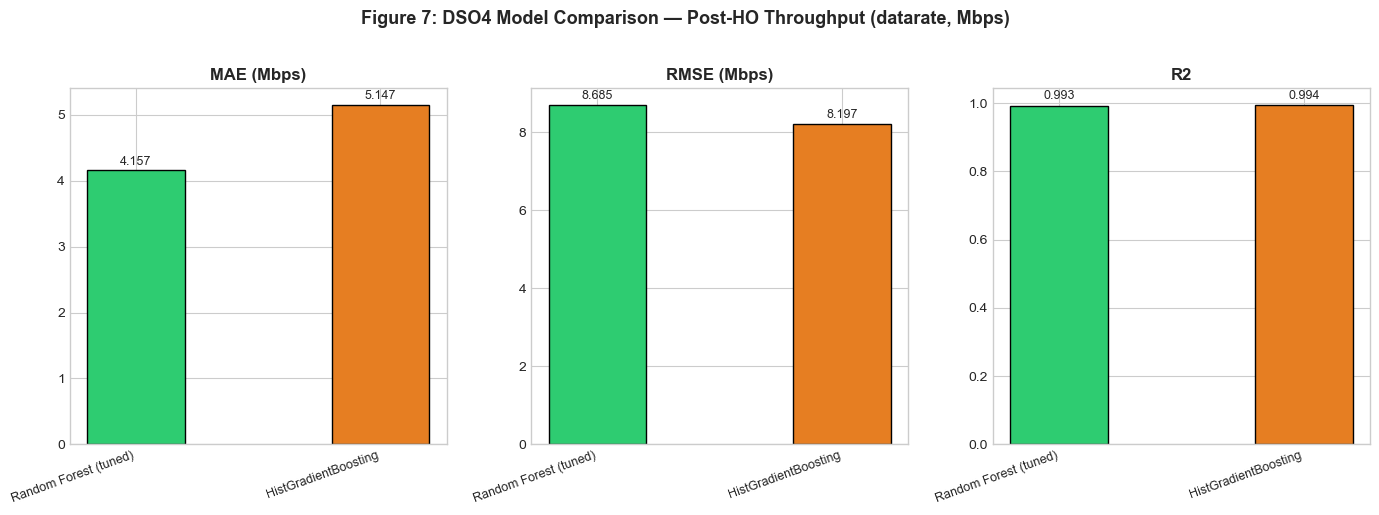

✅ Saved: dso4_model_comparison.png


In [35]:
# ── Figure 7: Model comparison bar chart ──────────────────────────────────────
if dso4_preds:
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    colors = ['#2ecc71', '#e67e22']

    for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
        vals = results_df[metric]
        bars = ax.bar(vals.index, vals, color=colors[:len(vals)], edgecolor='black', width=0.4)
        unit = 'Mbps' if metric in ['MAE', 'RMSE'] else ''
        ax.set_title(f'{metric} ({unit})' if unit else metric, fontweight='bold', fontsize=12)
        ax.set_xticklabels(vals.index, rotation=20, ha='right', fontsize=9)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=9)

    plt.suptitle('Figure 7: DSO4 Model Comparison — Post-HO Throughput (datarate, Mbps)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('dso4_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: dso4_model_comparison.png')

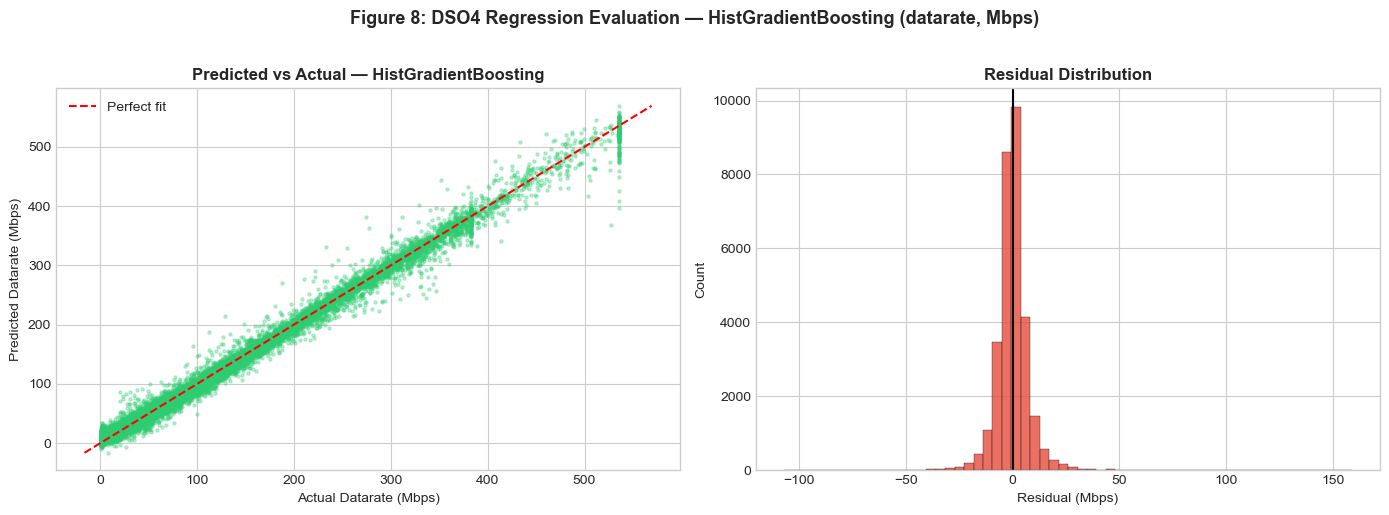

✅ Saved: dso4_regression_evaluation.png


In [37]:
# ── Figure 8: Predicted vs Actual + Residuals (best model) ────────────────────
if dso4_preds:
    y_true_best, y_pred_best = dso4_preds[best_name]
    residuals = np.array(y_true_best) - np.array(y_pred_best)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter: predicted vs actual
    axes[0].scatter(y_true_best, y_pred_best, alpha=0.3, s=5, color='#2ecc71')
    lo = min(np.min(y_true_best), np.min(y_pred_best))
    hi = max(np.max(y_true_best), np.max(y_pred_best))
    axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')
    axes[0].set_xlabel('Actual Datarate (Mbps)')
    axes[0].set_ylabel('Predicted Datarate (Mbps)')
    axes[0].set_title(f'Predicted vs Actual — {best_name}', fontweight='bold')
    axes[0].legend()

    # Residuals
    axes[1].hist(residuals, bins=60, color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.3)
    axes[1].axvline(0, color='black', linewidth=1.5)
    axes[1].set_xlabel('Residual (Mbps)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Residual Distribution', fontweight='bold')

    plt.suptitle(f'Figure 8: DSO4 Regression Evaluation — {best_name} (datarate, Mbps)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('dso4_regression_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: dso4_regression_evaluation.png')

In [47]:
# ── Figure 9: Feature importance (Random Forest) ──────────────────────────────
if 'Random Forest' in dso4_models and hasattr(dso4_models['Random Forest'], 'feature_importances_'):
    fi = pd.Series(
        dso4_models['Random Forest'].feature_importances_,
        index=dso4_feats
    ).sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 5))
    fi.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='black')
    ax.set_xlabel('Feature Importance (mean decrease impurity)')
    ax.set_title(
        'Figure 9: DSO4 — Top 15 Feature Importances (Random Forest, Post-HO Datarate)',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('dso4_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: dso4_feature_importance.png')
else:
    print('⚠️  Feature importance not available.')

⚠️  Feature importance not available.


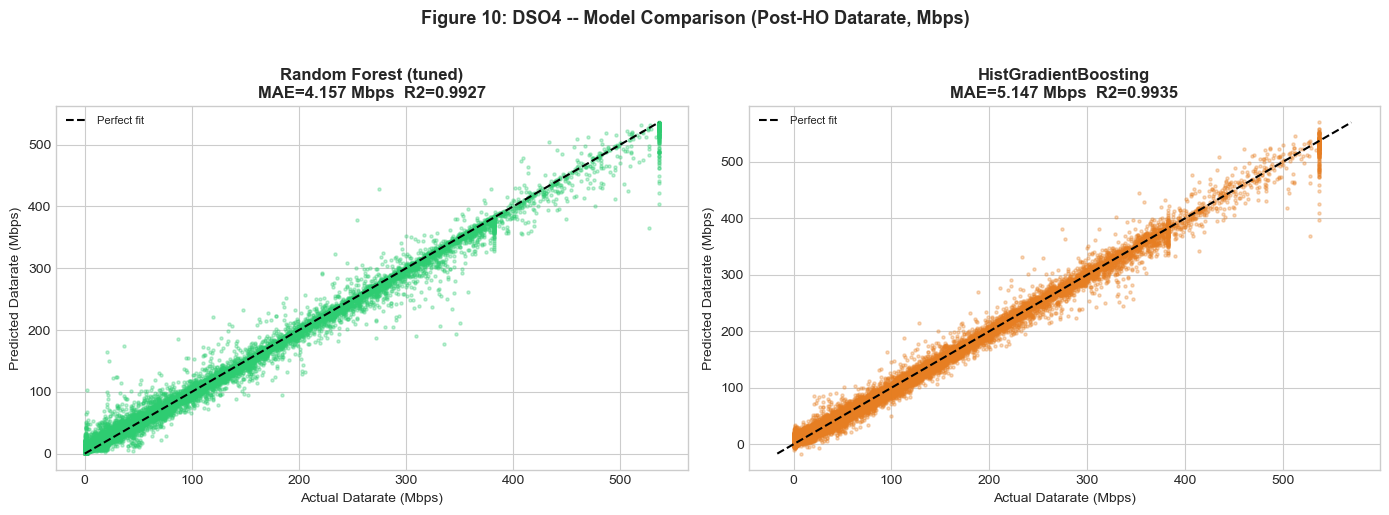

Saved: dso4_rf_vs_gb.png


In [39]:
# Figure 10: Model comparison scatter
model_names = list(dso4_preds.keys())[:2]
colors = ['#2ecc71', '#e67e22']
if len(model_names) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, model_name, color in zip(axes, model_names, colors):
        y_true_m, y_pred_m = dso4_preds[model_name]
        ax.scatter(y_true_m, y_pred_m, alpha=0.3, s=5, color=color)
        lo = min(np.min(y_true_m), np.min(y_pred_m))
        hi = max(np.max(y_true_m), np.max(y_pred_m))
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Perfect fit')
        mae_m = mean_absolute_error(y_true_m, y_pred_m)
        r2_m  = r2_score(y_true_m, y_pred_m)
        ax.set_title(f'{model_name}\nMAE={mae_m:.3f} Mbps  R2={r2_m:.4f}', fontweight='bold')
        ax.set_xlabel('Actual Datarate (Mbps)')
        ax.set_ylabel('Predicted Datarate (Mbps)')
        ax.legend(fontsize=8)
    plt.suptitle('Figure 10: DSO4 -- Model Comparison (Post-HO Datarate, Mbps)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('dso4_rf_vs_gb.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: dso4_rf_vs_gb.png')


In [40]:
# ── Final summary ──────────────────────────────────────────────────────────────
if dso4_preds:
    print(f"\n{'='*62}")
    print('  DSO4 — FINAL EVALUATION SUMMARY')
    print('  Post-Handover Throughput Prediction (datarate, Mbps)')
    print(f"{'='*62}")
    print(results_df.round(4).to_string())
    print(f"\n  🏆 Best model by MAE: {best_name}")
    print(f"{'='*62}")
    print()
    print('  Target   : datarate (Mbps) — iperf_data [genuinely continuous]')
    print('  Dropped  : mean_latency — near-constant in DoNext, clipping')
    print('             collapses injected noise to 2 boundary values')
    print('  Models   : Random Forest, Gradient Boosting')


  DSO4 — FINAL EVALUATION SUMMARY
  Post-Handover Throughput Prediction (datarate, Mbps)
                          MAE    RMSE      R2
Model                                        
Random Forest (tuned)  4.1573  8.6852  0.9927
HistGradientBoosting   5.1467  8.1966  0.9935

  🏆 Best model by MAE: HistGradientBoosting

  Target   : datarate (Mbps) — iperf_data [genuinely continuous]
  Dropped  : mean_latency — near-constant in DoNext, clipping
             collapses injected noise to 2 boundary values
  Models   : Random Forest, Gradient Boosting



DSO4 -- Accuracy Metrics (Post-HO Throughput)
  Model                            ±10% Acc   ±20% Acc    ±10Mbps    ±20Mbps
  -----------------------------------------------------------------
  Random Forest (tuned)              75.05%     85.17%     90.38%     96.63%
  HistGradientBoosting               64.86%     80.87%     87.78%     97.26%


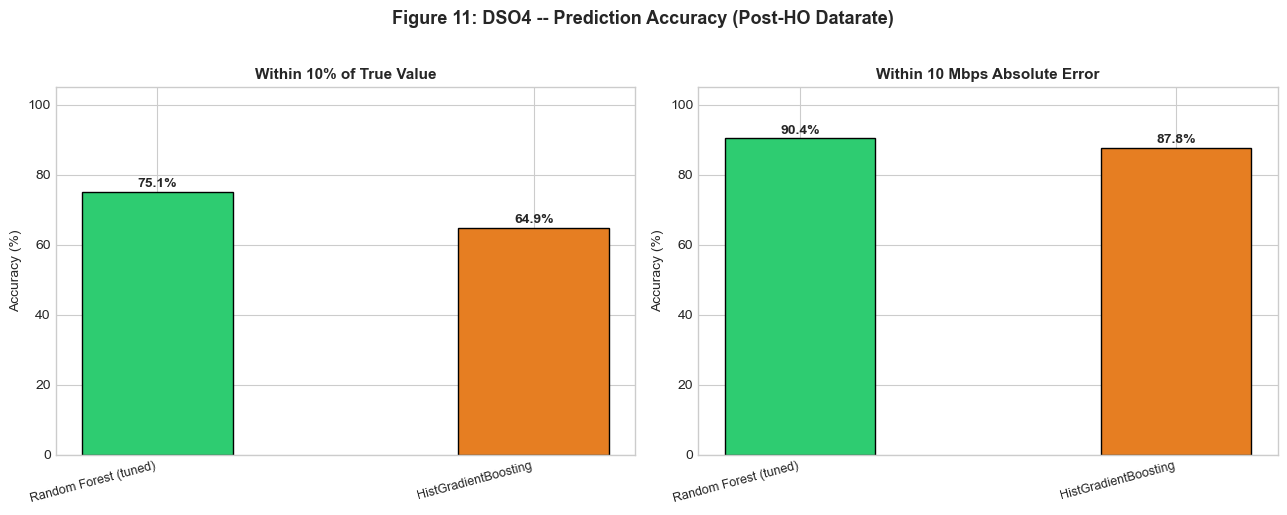

Saved: dso4_accuracy.png


In [45]:
# Accuracy metrics (Within-tolerance accuracy)
print('\n' + '='*62)
print('DSO4 -- Accuracy Metrics (Post-HO Throughput)')
print('='*62)
print(f'  {"Model":<30} {"±10% Acc":>10} {"±20% Acc":>10} {"±10Mbps":>10} {"±20Mbps":>10}')
print(f'  {"-"*65}')

accuracy_rows = []
for name, (y_true, y_pred) in dso4_preds.items():
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    nonzero = y_true_arr > 0
    pct_err = np.abs(y_true_arr[nonzero] - y_pred_arr[nonzero]) / y_true_arr[nonzero]
    acc_10pct  = (pct_err <= 0.10).mean() * 100
    acc_20pct  = (pct_err <= 0.20).mean() * 100
    abs_err    = np.abs(y_true_arr - y_pred_arr)
    acc_10mbps = (abs_err <= 10).mean() * 100
    acc_20mbps = (abs_err <= 20).mean() * 100
    accuracy_rows.append({'Model': name, 'Within 10%': acc_10pct,
                          'Within 20%': acc_20pct, 'Within 10Mbps': acc_10mbps, 'Within 20Mbps': acc_20mbps})
    print(f'  {name:<30} {acc_10pct:>9.2f}% {acc_20pct:>9.2f}% {acc_10mbps:>9.2f}% {acc_20mbps:>9.2f}%')

accuracy_df = pd.DataFrame(accuracy_rows).set_index('Model')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2ecc71', '#e67e22']
for ax, (col, title) in zip(axes, [('Within 10%', 'Within 10% of True Value'),
                                    ('Within 10Mbps', 'Within 10 Mbps Absolute Error')]):
    vals = accuracy_df[col]
    bars = ax.bar(vals.index, vals, color=colors[:len(vals)], edgecolor='black', width=0.4)
    ax.set_ylim(0, 105)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticklabels(vals.index, rotation=15, ha='right', fontsize=9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Figure 11: DSO4 -- Prediction Accuracy (Post-HO Datarate)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dso4_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dso4_accuracy.png')